In [6]:
'''
Use data from the literature to directly compare autaptic and synapse properties

'''

import numpy as np
import pandas as pandas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# AQUA supplies the neuron/autapse model wrapper used to build Brian2 objects.
import aqua
from aqua.batchAQUA_general import batchAQUA

# Brian2 units, monitors, and network primitives are imported into the namespace.
from brian2 import *

In [7]:
# import data 

filename = 'autapse_properties_updated.csv'
df = pd.read_csv(filename)
print(df.keys())

df['Study'] = df['Author'] + " (" + df['Year'].astype(str) + ")"

print(df.head())


Index(['Author', 'Year', 'autapse', 'neuron type', 'E/I', 'peak current (pA)',
       'peak current (pA)_std', 'CV aEPSC', 'CV aEPSC_std', 'failure rate',
       'failure rate_std', 'onset latency (ms)', 'onset latency (ms)_std',
       'rise time (ms)', 'rise time (ms)_std', 'decay time (ms)',
       'decay time (ms)_std', 'probability of release',
       'probability of release_std', 'paired-pulse ratio',
       'paired-pulse ratio_std'],
      dtype='object')
           Author  Year  autapse neuron type E/I  peak current (pA)  \
0      Yin et al.  2018     True          PC   E             149.00   
1      Yin et al.  2018    False       PC-PC   E              28.60   
2    Bacci et al.  2003     True          FS   I            -352.30   
3  Deleuze et al.  2019     True          PV   I            -451.82   
4  Deleuze et al.  2019    False       PV-PC   I            -146.87   

   peak current (pA)_std  CV aEPSC  CV aEPSC_std  failure rate  ...  \
0                  11.00      0.25 

In [8]:
## Only look at the studies which look explicitly compare autapses to synapses.

# Clean up trailing whitespace in string columns if present
df['Author'] = df['Author'].str.strip()

# Convert autapse column values to standardized boolean/string representation
df['autapse_bool'] = df['autapse'].astype(str).str.upper()

# Filter groups that contain both 'TRUE' and 'FALSE'
filtered_df = df.groupby(['Author', 'Year']).filter(
    lambda group: {'TRUE', 'FALSE'}.issubset(set(group['autapse_bool']))
).drop(columns=['autapse_bool'])
filtered_df['Study'] = filtered_df['Author'] + " (" + filtered_df['Year'].astype(str) + ")"
# Print the resulting DataFrame
print(filtered_df.keys())



Index(['Author', 'Year', 'autapse', 'neuron type', 'E/I', 'peak current (pA)',
       'peak current (pA)_std', 'CV aEPSC', 'CV aEPSC_std', 'failure rate',
       'failure rate_std', 'onset latency (ms)', 'onset latency (ms)_std',
       'rise time (ms)', 'rise time (ms)_std', 'decay time (ms)',
       'decay time (ms)_std', 'probability of release',
       'probability of release_std', 'paired-pulse ratio',
       'paired-pulse ratio_std', 'Study'],
      dtype='object')


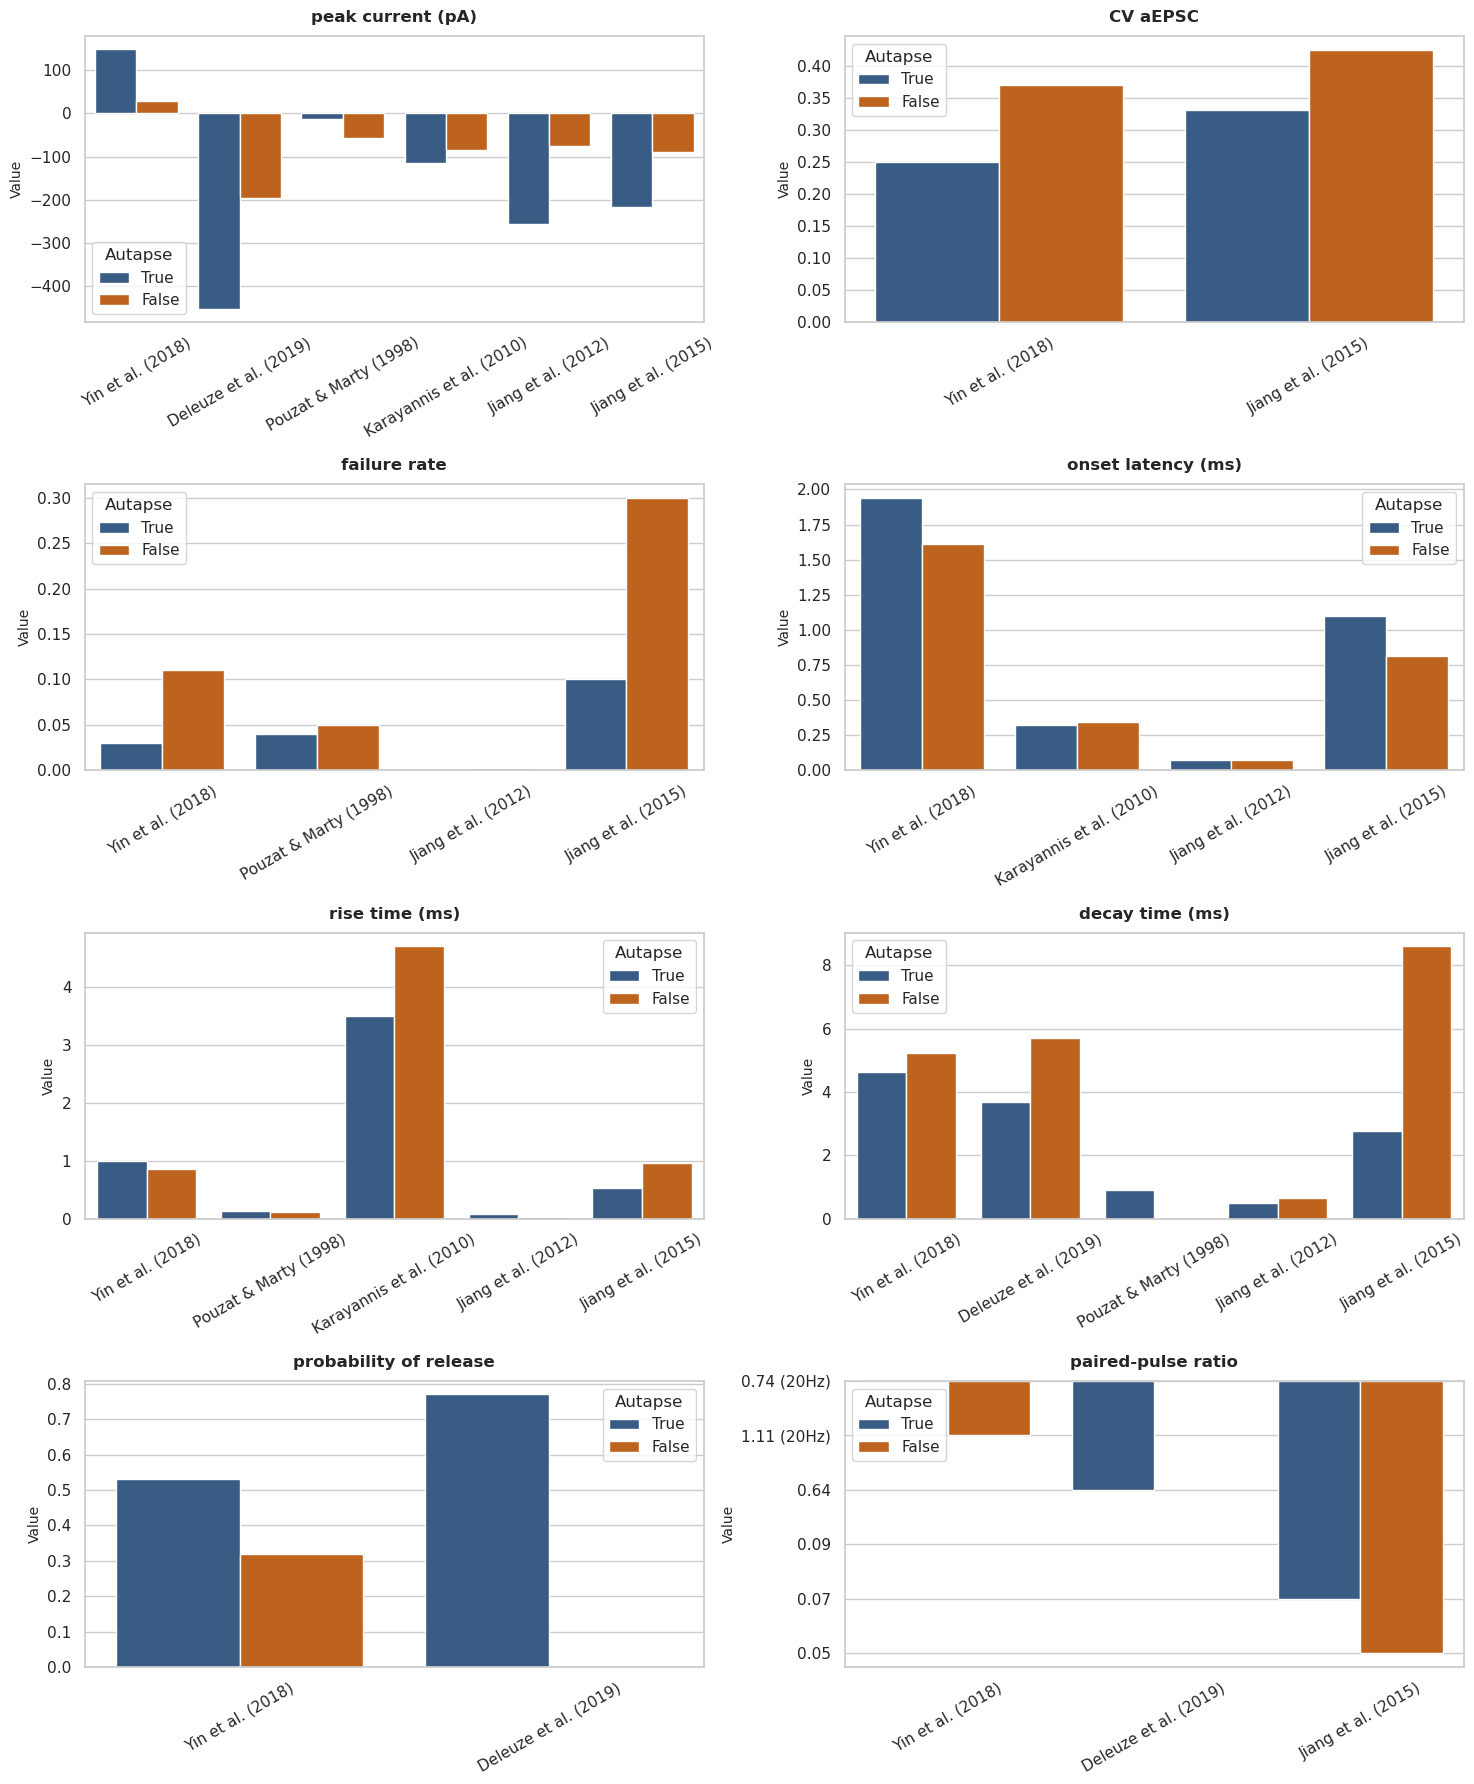

In [9]:
## SUPPLEMENTARY FIGURE
# 3. Measurement parameters
num_cols = [
    'peak current (pA)', 'CV aEPSC', 'failure rate', 
    'onset latency (ms)', 'rise time (ms)', 'decay time (ms)', 
    'probability of release', 'paired-pulse ratio'
]

def parse_val_and_std(val):
    """Parses cell string to extract numeric mean and standard deviation."""
    if pd.isna(val) or str(val).strip() in ['n/a', '']:
        return np.nan, np.nan
    
    clean_str = str(val).split('(')[0].strip()  # Strip frequency annotations like (20Hz)
    
    if '±' in clean_str:
        parts = clean_str.split('±')
        return float(parts[0].strip()), float(parts[1].strip())
    elif '+-' in clean_str:
        parts = clean_str.split('+-')
        return float(parts[0].strip()), float(parts[1].strip())
    else:
        try:
            return float(clean_str), np.nan
        except ValueError:
            return np.nan, np.nan

# Extract mean values (_val) and standard deviations (_std)
for col in num_cols:
    res = filtered_df[col].apply(parse_val_and_std)
    filtered_df[col + '_val'] = [r[0] for r in res]
    filtered_df[col + '_std'] = [r[1] for r in res]

# 4. Generate plots with custom _std error bars
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

sns.set_theme(style="whitegrid")
palette = {True: '#2b5c8f', False: '#d95f02'}
hue_order = [True, False]

for i, col in enumerate(num_cols):
    ax = axes[i]
    val_col = col
    std_col = col + '_std'
    
    sub_df = filtered_df.dropna(subset=[val_col])
    
    if not sub_df.empty:
        # Plot primary bars without auto-generated Seaborn error bars
        sns.barplot(
            data=sub_df, 
            x='Study', 
            y=val_col, 
            hue='autapse', 
            hue_order=hue_order,
            ax=ax,
            palette=palette,
            errorbar= None
        )

        
        # Calculate precise x positions to align error bars onto grouped bars
        studies = sub_df['Study'].unique()
        n_hues = len(hue_order)
        width = 0.8 / n_hues  # Standard bar width ratio in Seaborn
        
        for study_idx, study in enumerate(studies):
            for hue_idx, hue_val in enumerate(hue_order):
                row = sub_df[(sub_df['Study'] == study) & (sub_df['autapse'] == hue_val)]
                
                if not row.empty:
                    y_val = row[val_col].values[0]
                    y_err = row[std_col].values[0]
                    
                    # Plot error bar if _std exists and is valid
                    if not np.isnan(y_err):
                        x_pos = study_idx + (hue_idx - (n_hues - 1) / 2) * width
                        ax.errorbar(
                            x=x_pos, 
                            y=y_val, 
                            yerr=y_err, 
                            fmt='none', 
                            c='black', 
                            capsize=4, 
                            capthick=1.2, 
                            elinewidth=1.2
                        )
        
        ax.set_title(col, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('Value', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(title='Autapse', frameon=True)
    else:
        ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', 
                verticalalignment='center', transform=ax.transAxes, color='gray')
        ax.set_title(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('Supplementary Plots/autapse_custom_errorbars.png', dpi=300)
plt.show()

In [10]:
## Calculate the ratios

# 1. Define numerical value columns to clean and calculate
value_cols = [
    'peak current (pA)', 'CV aEPSC', 'failure rate', 
    'onset latency (ms)', 'rise time (ms)', 'decay time (ms)', 
    'probability of release', 'paired-pulse ratio'
]

# Ensure values are clean numeric floats
for col in value_cols:
    df[col] = df[col].astype(str).str.split('(').str[0].str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean autapse column
df['autapse_str'] = df['autapse'].astype(str).str.upper()

# 2. Separate into TRUE and FALSE subsets (include 'E/I' in true_df)
true_df = df[df['autapse_str'] == 'TRUE'].copy()
false_df = df[df['autapse_str'] == 'FALSE'].copy()

# 3. Merge on 'Study' (carrying over 'E/I' from the autaptic/TRUE condition)
pairwise = pd.merge(
    true_df[['Study', 'E/I', 'neuron type'] + value_cols],
    false_df[['Study', 'neuron type'] + value_cols],
    on='Study',
    suffixes=('_aut', '_non_aut')
)

# 4. Calculate ratio (True / False) for each parameter
ratio_cols = []
for col in value_cols:
    ratio_col_name = f"{col}_ratio"
    pairwise[ratio_col_name] = pairwise[f"{col}_aut"] / pairwise[f"{col}_non_aut"]
    ratio_cols.append(ratio_col_name)

# 5. Select display columns with E/I included
display_cols = ['Study', 'E/I', 'neuron type_aut', 'neuron type_non_aut'] + ratio_cols
ratios_df = pairwise[display_cols]

# Optional: rename 'E/I' column for clarity
ratios_df = ratios_df.rename(columns={'E/I': 'E/I_autaptic'})

print(ratios_df)

                       Study E/I_autaptic neuron type_aut neuron type_non_aut  \
0          Yin et al. (2018)            E              PC               PC-PC   
1      Deleuze et al. (2019)            I              PV               PV-PC   
2      Deleuze et al. (2019)            I              PV               PV-PV   
3      Pouzat & Marty (1998)            I             NaN                 NaN   
4   Karayannis et al. (2010)            I            NGFC                NGFC   
5        Jiang et al. (2012)            I              FS               FS-FS   
6        Jiang et al. (2012)            I              FS               FS-PC   
7        Jiang et al. (2015)            I   FS (juvenile)    FS-PC (juvenile)   
8        Jiang et al. (2015)            I   FS (juvenile)       FS-PC (adult)   
9        Jiang et al. (2015)            I      FS (adult)    FS-PC (juvenile)   
10       Jiang et al. (2015)            I      FS (adult)       FS-PC (adult)   

    peak current (pA)_ratio

Index(['Study', 'E/I_autaptic', 'neuron type_aut', 'neuron type_non_aut',
       'peak current (pA)_ratio', 'CV aEPSC_ratio', 'failure rate_ratio',
       'onset latency (ms)_ratio', 'rise time (ms)_ratio',
       'decay time (ms)_ratio', 'probability of release_ratio',
       'paired-pulse ratio_ratio'],
      dtype='object')


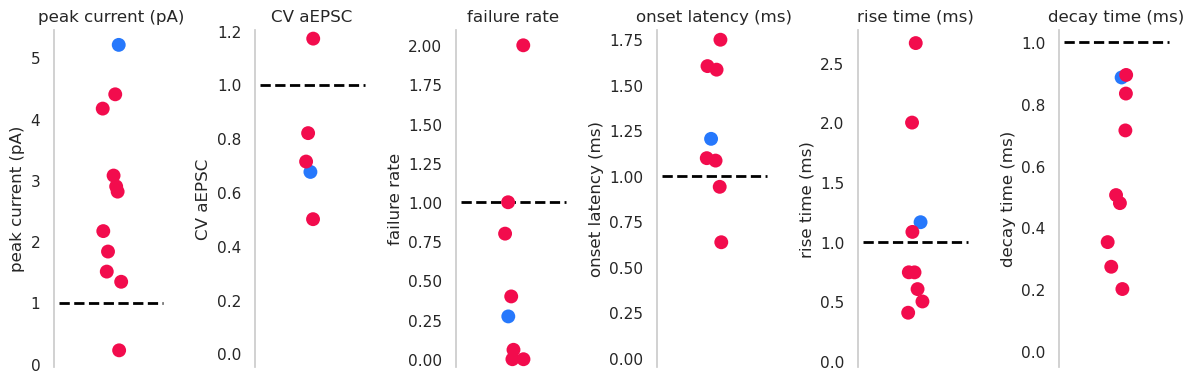

In [11]:
print(ratios_df.keys())

cols = ['peak current (pA)_ratio', 'CV aEPSC_ratio', 'failure rate_ratio',
       'onset latency (ms)_ratio', 'rise time (ms)_ratio',
       'decay time (ms)_ratio']
# 'probability of release_ratio', 'paired-pulse ratio_ratio']

fig, ax = plt.subplots(1, len(cols), figsize = (2*len(cols), 4))
sns.despine(fig = fig, bottom = True, top = True, right = True)
palette = {'E': "#2678fc", 'I': "#f20c4d"}

for n, col in enumerate(cols):
    sns.stripplot(data = ratios_df, y = col, hue = 'E/I_autaptic', palette = palette, ax = ax[n], legend = False,
                  size = 10)
    ax[n].hlines(y = 1.0, xmin = ax[n].get_xlim()[0], xmax = ax[n].get_xlim()[1], 
                 linestyle = '--', color = 'black', linewidth = 2)
    ax[n].set_title(col[:-6])
    ax[n].set_ylabel(col[:-6])
    ax[n].grid(False)
    ax[n].set_ylim(bottom = -0.05)

fig.tight_layout()
plt.savefig('./plots/Figure 2/ratio_autapse_properties.svg')


WARNING    /tmp/ipykernel_7060/1032723905.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['age'] = ['juvenile', 'juvenile', 'adult', 'adult']
 [py.warnings]


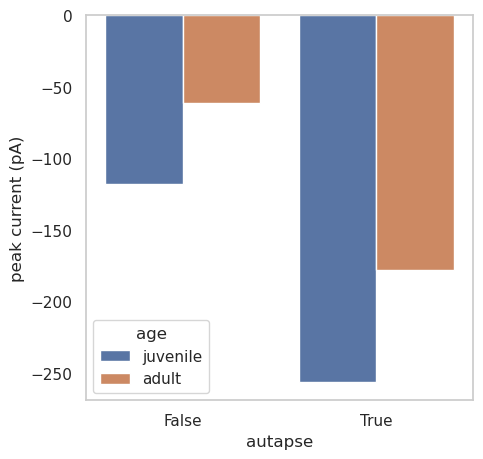

In [12]:
### Show data comparing juvenile versus adult autapse strength

sub_df = df[df['Study'] == 'Jiang et al. (2015)']

sub_df['age'] = ['juvenile', 'juvenile', 'adult', 'adult']

fig, ax = plt.subplots(1, 1, figsize = (5, 5))

sns.barplot(data = sub_df, x = 'autapse', y = 'peak current (pA)', hue = 'age', ax = ax)
ax.grid(False)

plt.savefig('./plots/Figure 2/Age_comparison.svg')